# Тематическое моделирование по данным nsk-kraeved.ru

Тот же датасет, что и в `hw07.ipynb` (тексты тем краеведческого форума
nsk-kraeved.ru), но задача другая: не предсказать просмотры, а без учителя
выделить скрытые темы обсуждений (LDA и NMF) и посмотреть, насколько они
согласуются с реальными разделами форума (`forum_name`).


## Загрузка и очистка данных

Используем ту же очистку текста, что и в `hw07.ipynb`: убираем автослужебные
пометки форума (`Отредактировано ... (дата)`), приписки при цитировании
(`<ник> написал(а):`) и ссылки (`https://...`) — иначе они попадают в словарь
как "темы" сами по себе (ссылки на Google Maps/сканы документов давали темы
вида "https, pdf, ru, google, maps" — это технический мусор, а не содержание).


In [1]:
import re

import pandas as pd

df = pd.read_csv("data/nsk_kraeved_topics.csv")
df["text"] = df["text"].fillna("").astype(str)

URL_RE = re.compile(r"(https?://\S+)|(\bwww\.\S+)", re.UNICODE)
EDIT_NOTICE_RE = re.compile(r"Отредактировано[^)]*\)", re.UNICODE)
QUOTE_ATTR_RE = re.compile(r"[^\s]+(?:\s+[^\s]+){0,2}\s*написал\(а\):", re.UNICODE)


def clean_text(text):
    text = URL_RE.sub(" ", text)
    text = EDIT_NOTICE_RE.sub(" ", text)
    text = QUOTE_ATTR_RE.sub(" ", text)
    return text


df["text"] = df["text"].map(clean_text)
df = df[df["text"].str.len() >= 30].reset_index(drop=True)
print(df.shape)
df.head(3)


(14388, 9)


,forum_id,forum_name,topic_id,title,views,replies,text,created_ts,scraped_ts
0,51,Новониколаевск,17942,Фотографии... ?,138,4,"... Что-нибудь, связанное с Что-нибудь, с...",1786179451,1786263980
1,51,Новониколаевск,17902,Горюшкин Первые жители Новониколаевска(1893—18...,61,1,/// Горюшкин Леонид Михайлович_Первые жители...,1785445772,1786263982
2,51,Новониколаевск,375,Военный городок,13365,170,. Городок на Тополёвой? Верно. Надпись на обр...,1254580933,1786263984


## Векторизация

Для LDA нужны "сырые" счётчики слов (LDA моделирует мультиномиальное
распределение по словам), для NMF — TF-IDF (даёт более чистые темы на
разреженных матрицах). В обоих случаях: только униграммы (для тематического
моделирования биграммы обычно только шумят), русские стоп-слова, токен —
только буквы (без дат/номеров), отсекаем слишком редкие и слишком частые
слова.

Первый прогон (см. ниже, если запускать со стандартным списком стоп-слов nltk)
даёт темы, забитые разговорными словами-паразитами форума ("ещё", "всё",
"очень", "просто", "вроде", "точно", "почему", "хотя", "возможно") и
словоформами "год/года/году/лет" — они встречаются почти в каждом сообщении
("а в каком году это построили?"), но не различают темы между собой. На полном
датасете (все 132 подфорума) к ним добавилось слово "фото" — в любой теме
форума, независимо от объекта, кто-то пишет "вот фото" или "есть фото?", из-за
чего оно оказалось топ-словом почти в каждой теме LDA. Расширяем стоп-слова
этими словами специально для данного корпуса.


In [2]:
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

russian_stopwords = stopwords.words("russian")

# специфичные для этого форума слова-паразиты и словоформы "год"/"фото", которые
# не несут различительной информации между темами (см. markdown выше)
CORPUS_SPECIFIC_STOPWORDS = [
    "ещё", "всё", "очень", "просто", "вроде", "точно", "почему", "хотя",
    "вообще", "возможно", "стоит", "эта", "этот", "эти", "этой", "этом",
    "года", "году", "год", "годы", "лет", "фото",
]
russian_stopwords = russian_stopwords + CORPUS_SPECIFIC_STOPWORDS

VECTORIZER_PARAMS = dict(
    ngram_range=(1, 1),
    stop_words=russian_stopwords,
    min_df=5,
    max_df=0.5,
    token_pattern=r"(?u)\b[а-яёa-z]{2,}\b",
)

count_vectorizer = CountVectorizer(**VECTORIZER_PARAMS)
X_counts = count_vectorizer.fit_transform(df["text"])

tfidf_vectorizer = TfidfVectorizer(**VECTORIZER_PARAMS)
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

print("counts:", X_counts.shape, " tfidf:", X_tfidf.shape)


counts: (14388, 52938)  tfidf: (14388, 52938)


## LDA (Latent Dirichlet Allocation)

Число тем — гиперпараметр; берём 15 как разумный компромисс между 27 реальными
подфорумами (слишком дробно для LDA на ~3.7 тыс. документов) и слишком грубым
делением.


In [3]:
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 15

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method="batch",
    random_state=42,
)
lda_doc_topic = lda.fit_transform(X_counts)
print("doc-topic matrix:", lda_doc_topic.shape)


doc-topic matrix: (14388, 15)


In [4]:
import numpy as np


def top_words_per_topic(components, feature_names, n_top=12):
    tops = []
    for topic in components:
        top_idx = np.argsort(topic)[::-1][:n_top]
        tops.append([(feature_names[i], topic[i]) for i in top_idx])
    return tops


count_feature_names = np.array(count_vectorizer.get_feature_names_out())
lda_top_words = top_words_per_topic(lda.components_, count_feature_names)

for i, words in enumerate(lda_top_words):
    print(f"Тема {i}: " + ", ".join(w for w, _ in words))


Тема 0: верно, здание, слева, ответ, ул, похоже, справа, проспект, пр, дк, дома, маркса
Тема 1: дом, здание, дома, здания, ул, доме, магазин, адрес, здании, месте, этаже, красный
Тема 2: дома, ул, дом, улица, улицы, видно, слева, справа, место, месте, плане, домов
Тема 3: завод, завода, время, которые, человек, который, новосибирске, ссср, войны, нам, несколько, новосибирский
Тема 4: школа, школы, школу, школе, здание, училище, школ, отдыха, санаторий, лагерь, школой, района
Тема 5: вопрос, тему, спасибо, темы, знаю, форуме, форума, фильм, тема, ответ, интересно, могу
Тема 6: въ, съ, время, жизни, её, жизнь, театра, театр, детей, новосибирске, изъ, къ
Тема 7: мост, моста, обь, новосибирск, самолет, театра, авиации, время, толмачево, оби, метров, новосибирске
Тема 8: новосибирска, памятник, города, новосибирск, музей, pdf, новосибирской, культуры, области, музея, новосибирске, номер
Тема 9: сибири, ссср, новосибирск, войны, сибирского, гг, новосибирске, россии, института, области, сибир

## NMF (Non-negative Matrix Factorization) — для сравнения

In [5]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=N_TOPICS, init="nndsvd", random_state=42, max_iter=500)
nmf_doc_topic = nmf.fit_transform(X_tfidf)

tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
nmf_top_words = top_words_per_topic(nmf.components_, tfidf_feature_names)

for i, words in enumerate(nmf_top_words):
    print(f"Тема {i}: " + ", ".join(w for w, _ in words))


Тема 0: новосибирск, города, сибири, новосибирска, новосибирске, новосибирской, области, ссср, истории, памятник, время, сибирь
Тема 1: pdf, еее, скан, сканы, истории, ред, сибири, vpn, ккк, история, ун, наука
Тема 2: рождения, днём, здоровья, днем, взломанный, сайт, поздравляю, счастья, удачи, благ, спасибо, успехов
Тема 3: дом, дома, доме, домов, жилой, улице, адрес, домик, построен, окна, урицкого, постройки
Тема 4: проспект, красный, кр, проспекта, красного, крылова, верно, морской, ковальчук, красном, дуси, слева
Тема 5: школа, школы, школу, школе, школ, школой, лицей, гимназия, средняя, учился, бывшая, класс
Тема 6: мост, помню, моста, знаю, именно, место, вопрос, время, интересно, месте, видно, наверное
Тема 7: ул, ленина, кирова, верно, станиславского, челюскинцев, богаткова, адрес, советская, горького, фрунзе, ответ
Тема 8: въ, съ, изъ, къ, отъ, какъ, ново, онъ, такъ, ихъ, подъ, сибири
Тема 9: здание, плане, здания, заднем, здании, оно, дк, похоже, корпус, адрес, фрунзе, месте

## Визуализация тем LDA

Топ-10 слов для каждой темы — вес слова в теме (магнитуда, не полярность),
поэтому один цвет (последовательная синяя шкала по рангу внутри темы).


In [6]:
import matplotlib.pyplot as plt

BLUE_RAMP = ["#184f95", "#1c5cab", "#256abf", "#2a78d6", "#3987e5", "#5598e7", "#6da7ec", "#86b6ef", "#9ec5f4", "#b7d3f6"]
GRID = "#e1e0d9"
TEXT_PRIMARY = "#0b0b0b"
TEXT_MUTED = "#898781"
SURFACE = "#fcfcfb"

n_cols = 3
n_rows = int(np.ceil(N_TOPICS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows), facecolor=SURFACE)
axes = axes.flatten()

for i, words in enumerate(lda_top_words):
    ax = axes[i]
    ax.set_facecolor(SURFACE)
    labels = [w for w, _ in words][::-1]
    values = [v for _, v in words][::-1]
    colors = BLUE_RAMP[: len(values)][::-1]
    ax.barh(range(len(labels)), values, color=colors, height=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8, color=TEXT_PRIMARY)
    ax.set_title(f"Тема {i} (LDA)", fontsize=10, color=TEXT_PRIMARY)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=7, colors=TEXT_MUTED)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

for j in range(len(lda_top_words), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("lda_topics.png", dpi=150, facecolor=SURFACE)
plt.show()


<Figure size 1400x1600 with 15 Axes>

## Размер тем и согласованность с реальными разделами форума

Каждой теме присваиваем документы по максимальной вероятности (`argmax`
по строкам `lda_doc_topic`), считаем, сколько документов попало в каждую
тему, и строим тепловую карту "тема LDA × реальный подфорум" — если темы
осмысленны, они должны концентрироваться в одном-двух родственных подфорумах.


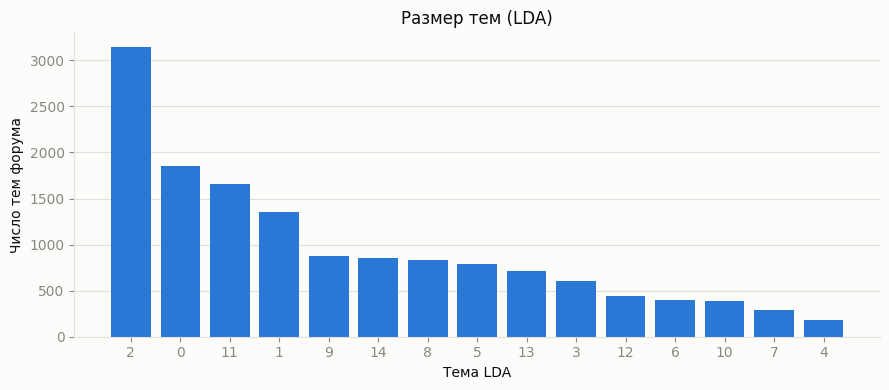

In [7]:
df["lda_topic"] = lda_doc_topic.argmax(axis=1)

topic_sizes = df["lda_topic"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
order = topic_sizes.sort_values(ascending=False)
ax.bar(order.index.astype(str), order.values, color="#2a78d6")
ax.set_xlabel("Тема LDA", color=TEXT_PRIMARY)
ax.set_ylabel("Число тем форума", color=TEXT_PRIMARY)
ax.set_title("Размер тем (LDA)", color=TEXT_PRIMARY)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.spines["left"].set_color(GRID)
ax.tick_params(colors=TEXT_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("lda_topic_sizes.png", dpi=150, facecolor=SURFACE)
plt.show()


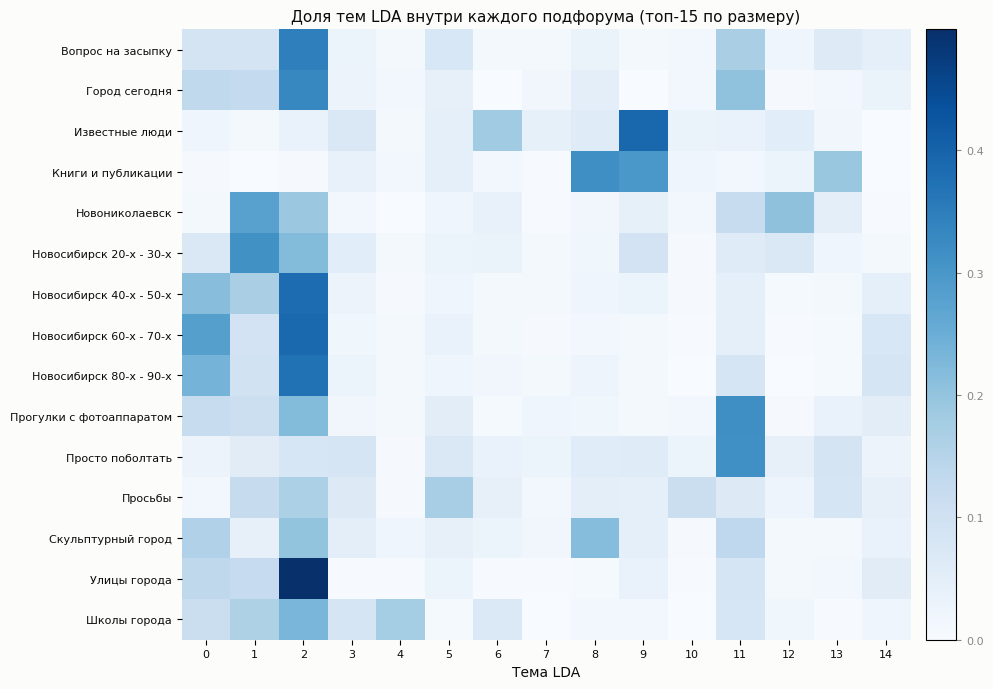

In [8]:
# оставляем только достаточно крупные подфорумы, чтобы карта была читаемой
top_forums = df["forum_name"].value_counts().head(15).index
sub = df[df["forum_name"].isin(top_forums)]

cross = pd.crosstab(sub["forum_name"], sub["lda_topic"])
cross_norm = cross.div(cross.sum(axis=1), axis=0)  # доля темы внутри подфорума

fig, ax = plt.subplots(figsize=(10, 7), facecolor=SURFACE)
im = ax.imshow(cross_norm.values, cmap="Blues", aspect="auto", vmin=0, vmax=cross_norm.values.max())
ax.set_xticks(range(cross_norm.shape[1]))
ax.set_xticklabels(cross_norm.columns, fontsize=8, color=TEXT_PRIMARY)
ax.set_yticks(range(cross_norm.shape[0]))
ax.set_yticklabels(cross_norm.index, fontsize=8, color=TEXT_PRIMARY)
ax.set_xlabel("Тема LDA", color=TEXT_PRIMARY)
ax.set_title("Доля тем LDA внутри каждого подфорума (топ-15 по размеру)", color=TEXT_PRIMARY, fontsize=11)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.ax.tick_params(colors=TEXT_MUTED, labelsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig("lda_forum_heatmap.png", dpi=150, facecolor=SURFACE)
plt.show()


## Интерпретация

Этот прогон — на полном сайте (все 132 подфорума, ~14.4 тыс. тем), а не на
кураторской выборке из 27 исторических разделов, как в первой версии разбора.
Как и в `hw07.ipynb`, полный охват потребовал ещё одной итерации чистки:
слово "фото" — универсальный "дежурный" токен, который встречается в любой
теме независимо от объекта, а ссылки на Google Maps/сканы документов
(`https`, `pdf`, `google`, `maps`) занимали место содержательных слов, пока их
не вырезали регулярным выражением (см. код очистки выше).

**Наиболее чёткие темы LDA** явно привязаны к конкретному типу объекта:

- Тема 4 — *школа, училище, санаторий, лагерь* — учебные и детские учреждения;
- Тема 7 — *мост, обь, самолёт, толмачёво, авиации* — мосты и, неожиданно, в
  одной теме с ними авиация/аэропорт Толмачёво (видимо, из-за общей лексики
  "рядом с рекой/окраиной города");
- Тема 12 — *ново, церкви, дороги, новониколаевска, железной* — дореволюционный
  Ново-Николаевск, церкви и железная дорога;
- Тема 13 — *оби, берегу, карте, кривощёково* — география реки Обь и
  Кривощёкова (историческое село на месте современного города);
- Тема 14 — *ул, остановка, трамвай, автобус, метро, депо* — городской
  транспорт;
- Тема 6 — *въ, съ, изъ, къ* — не тематическая, а **орфографическая**: тексты
  и вырезки со старой (дореволюционной) орфографией.

**Совсем новая, неожиданная тема — тема 10: *рождения, днём, спасибо, сайт,
взломанный, здоровья, поздравляю*.** Это тема поздравлений с днём рождения из
разговорных разделов ("Просто поболтать" и т.п.), которых не было в
кураторской выборке из 27 исторических разделов. Модель без единой метки
отделила чисто социальную активность форума (поздравления, общение) от
краеведческого контента — хорошая иллюстрация того, что "полный сайт" — это
не только история города, но и обычная жизнь онлайн-сообщества. Слово
"взломанный" (сайт) снова всплыло, как и в `hw07.ipynb` — видимо, это
объявление администрации форума разошлось по многим темам с поздравлениями.

**Тепловая карта** (тема LDA × реальный подфорум, топ-15 по размеру) хорошо
подтверждает модель: "Улицы города" почти целиком (тёмная ячейка) лежит в
теме 2 (*дома, ул, дом, улица, видно*), "Известные люди" и "Книги и
публикации" концентрируются в теме 9 (*сибири, ссср, войны, института* —
общеисторический контекст), а "Прогулки с фотоаппаратом" — в теме 11
(*именно, время, такие, знаю, наверное* — разговорная тема без привязки к
объекту, комментарии к прогулкам). То есть unsupervised-модель самостоятельно
нашла значительную часть реальной структуры сайта, включая и не-исторические
разделы.

**NMF vs LDA.** Как и раньше, NMF на TF-IDF даёт более "острые", но иногда
переспециализированные темы — например, тема 11 NMF — список конкретных улиц
(*гоголя, крылова, мичурина, кошурникова, шамшиных*), которые часто
перечисляются вместе в темах-перекрёстках. У NMF также есть отдельная
"архивная" тема (*pdf, скан, сканы, ред, наука, ун*) — сборник ссылок на
отсканированные исторические документы, которые общий OCR-шум объединяет в
одну тему независимо от того, о каком объекте в них речь.

**Итог.** На полном сайте темы получились не только про историю города
(мосты, транспорт, школы, старая орфография), но и вскрыли социальный слой
форума — поздравления и бытовое общение, которых не видно при работе с
кураторской подвыборкой одних только исторических разделов. Это подтверждает,
что расширение охвата с 27 до 132 подфорумов дало не просто больше данных
того же типа, а качественно другую картину структуры сайта.
